# Exploratory Data Analysis (EDA) — Dataset IndoToxic2024
## Kelompok 4 — Workshop Proyek Sistem Cerdas 2026

**Mata Kuliah:** Workshop Proyek Sistem Cerdas 2026  
**Dosen Pengampu:** Dr. Selvia Ferdiana Kusuma, M.Kom  
**Dataset:** IndoToxic2024 / IndoDiscourse (Susanto et al., 2024, 2025)  
**Sumber:** [Exqrch/IndoDiscourse — HuggingFace](https://huggingface.co/datasets/Exqrch/IndoDiscourse)  

---

### Tujuan
Melakukan Exploratory Data Analysis (EDA) pada dataset IndoToxic2024, yaitu dataset teks berbahasa Indonesia yang digunakan untuk mengidentifikasi konten toksik, seperti ujaran kebencian, penghinaan, ancaman, atau bahasa kasar.

### Ruang Lingkup Analisis:
1. Memahami struktur dataset (jumlah data, nama kolom, tipe data, arti setiap label).
2. Memeriksa kualitas data (missing values, duplikat, teks outlier pendek/panjang, ketidakseimbangan kelas).
3. Menganalisis distribusi label toksik dan tidak toksik (tabel & grafik).
4. Menganalisis karakteristik teks (jumlah kata, panjang karakter, kata paling sering muncul, perbedaan pola tiap label).
5. Melakukan pembersihan awal teks (lowercase, hapus tanda baca, URL, emoji, kata tidak penting).
6. Menyajikan visualisasi hasil EDA (bar chart, histogram, word cloud / daftar kata dominan).
7. Menyusun kesimpulan dan rekomendasi persiapan data sebelum pelatihan model klasifikasi.

---
## 1. Setup & Pemuatan Dataset

In [3]:
import sys
from pathlib import Path
import ast
import re
import string
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set root path project
ROOT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from src.utils.config import Config
from src.utils.seed import set_seed

# Deterministik
set_seed(Config.SEED)

# Matplotlib style
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
sns.set_style('whitegrid')

print(f"Project Root : {ROOT_DIR}")
print(f"Seed         : {Config.SEED}")

Project Root : /home/josjiez/Documents/IndoToxic
Seed         : 42


In [4]:
# Muat dataset mentah
df_raw = pd.read_csv(ROOT_DIR / Config.RAW_DATA_CSV)
df_demo = pd.read_csv(ROOT_DIR / Config.RAW_DEMOGRAPHIC_CSV)

print(f"Total baris dataset teks       : {len(df_raw):,} data")
print(f"Total anotator yang terdaftar   : {len(df_demo):,} orang")

Total baris dataset teks       : 28,448 data
Total anotator yang terdaftar   : 29 orang


---
## 2. Memahami Struktur Dataset
### 2.1 Dimensi, Kolom, dan Tipe Data

In [5]:
print(f"Dimensi dataset : {df_raw.shape[0]:,} baris x {df_raw.shape[1]} kolom")
print("\n--- Daftar Kolom & Tipe Data ---")
print(df_raw.dtypes.to_string())
print("\n--- 5 Baris Pertama ---")
df_raw.head()

Dimensi dataset : 28,448 baris x 14 kolom

--- Daftar Kolom & Tipe Data ---
text_id                          str
annotators_id                    str
text                             str
initial_paragraph                str
topic                            str
is_noise_or_spam_text            str
related_to_election_2024         str
toxicity                         str
polarized                        str
profanity_obscenity              str
threat_incitement_to_violence    str
insults                          str
identity_attack                  str
sexually_explicit                str

--- 5 Baris Pertama ---


,text_id,annotators_id,text,initial_paragraph,topic,is_noise_or_spam_text,related_to_election_2024,toxicity,polarized,profanity_obscenity,threat_incitement_to_violence,insults,identity_attack,sexually_explicit
0,1-1,"['7', '15']",Wajah Jurnalis Dibalut Perban Saat Melaporkan ...,“️Jurnalis Hana Mahamed kembali tampil di tele...,UNKNOWN,"['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']"
1,1-10,"['7', '15']",Elektabilitas Paslon 02 sebentar lagi terjun b...,NaN,Disabilitas,"['0', '0']","['1', '1']","['0', '0']","['1', '1']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']"
2,1-100,"['7', '15']",Gini aja deh @KPU_ID usul aja nih. Gimana kalo...,NaN,Disabilitas,"['0', '0']","['1', '0']","['1', '0']","['0', '0']","['0', '0']","['0', '0']","['1', '0']","['0', '0']","['0', '0']"
3,1-1000,"['7', '15']",Relawan Tionghoa Kalbar yg di Jakarta mendekla...,NaN,Tionghoa,"['0', '0']","['1', '1']","['0', '0']","['1', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']"
4,1-1001,"['10', '18']","Kristen, Hindu, Islam dapat perlakuan istimewa...",NaN,Kristen,"['0', '0']","['1', '1']","['0', '0']","['1', '1']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']"


### 2.2 Kamus Kolom & Arti Setiap Label

| Kolom | Tipe | Deskripsi |
|---|---|---|
| `text_id` | str | Identifikator unik per baris teks |
| `annotators_id` | str (list) | ID anotator yang menilai teks ini |
| `text` | str | Teks media sosial asli (Twitter/X, Instagram, Facebook, berita) |
| `initial_paragraph` | str | Konteks/thread induk postingan |
| `topic` | str | Topik diskusi (Politik, Agama, SARA, Gender, Disabilitas, dll.) |
| `is_noise_or_spam_text` | str (list) | Vote apakah teks spam/noise (0/1) |
| `related_to_election_2024` | str (list) | Vote apakah terkait Pemilu 2024 (0/1) |
| `toxicity` | str (list) | **Label utama:** Vote toksisitas per anotator (0=Non-toxic, 1=Toxic) |
| `polarized` | str (list) | Vote apakah memicu polarisasi (0/1) |
| `profanity_obscenity` | str (list) | Sub-label: kata makian/vulgar |
| `threat_incitement_to_violence` | str (list) | Sub-label: ancaman kekerasan |
| `insults` | str (list) | Sub-label: penghinaan personal |
| `identity_attack` | str (list) | Sub-label: ujaran kebencian SARA |
| `sexually_explicit` | str (list) | Sub-label: konten seksual eksplisit |

---
## 3. Pemeriksaan Kualitas Data
### 3.1 Missing Values

In [6]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Jumlah Missing': missing, 'Persentase (%)': missing_pct})
missing_df = missing_df[missing_df['Jumlah Missing'] > 0].sort_values('Jumlah Missing', ascending=False)

if len(missing_df) > 0:
    print("Kolom dengan Missing Values:")
    print(missing_df)
else:
    print("Tidak ada missing values pada seluruh kolom.")

# Total missing pada kolom kritis
print(f"\nMissing pada kolom 'text'      : {df_raw['text'].isnull().sum()}")
print(f"Missing pada kolom 'toxicity'  : {df_raw['toxicity'].isnull().sum()}")
print(f"Missing pada kolom 'topic'     : {df_raw['topic'].isnull().sum()}")

Kolom dengan Missing Values:
                   Jumlah Missing  Persentase (%)
initial_paragraph           26779           94.13
text                            1            0.00

Missing pada kolom 'text'      : 1
Missing pada kolom 'toxicity'  : 0
Missing pada kolom 'topic'     : 0


### 3.2 Data Duplikat

In [7]:
n_dup_full = df_raw.duplicated().sum()
n_dup_text = df_raw.duplicated(subset=['text']).sum()

print(f"Baris duplikat (seluruh kolom)  : {n_dup_full:,}")
print(f"Baris duplikat (kolom 'text')   : {n_dup_text:,}")
print(f"Persentase duplikat teks        : {n_dup_text / len(df_raw) * 100:.2f}%")

if n_dup_text > 0:
    print(f"\nContoh teks yang duplikat:")
    dup_texts = df_raw[df_raw.duplicated(subset=['text'], keep=False)].sort_values('text')
    print(dup_texts[['text_id', 'text']].head(6).to_string(index=False))

Baris duplikat (seluruh kolom)  : 0
Baris duplikat (kolom 'text')   : 2,274
Persentase duplikat teks        : 7.99%

Contoh teks yang duplikat:
text_id                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

### 3.3 Teks Outlier (Terlalu Pendek / Terlalu Panjang)

In [8]:
# Hitung panjang kata dan karakter tanpa mengubah data teks asli
df_raw['word_count'] = df_raw['text'].apply(lambda x: len(str(x).split()) if pd.notna(x) else 0)
df_raw['char_count'] = df_raw['text'].apply(lambda x: len(str(x)) if pd.notna(x) else 0)

# Teks sangat pendek (1-2 kata)
short_texts = df_raw[df_raw['word_count'] <= 2]
# Teks sangat panjang (> 500 kata)
long_texts = df_raw[df_raw['word_count'] > 500]

print(f"Teks sangat pendek (≤ 2 kata)  : {len(short_texts):,} baris ({len(short_texts)/len(df_raw)*100:.2f}%)")
print(f"Teks sangat panjang (> 500 kata): {len(long_texts):,} baris ({len(long_texts)/len(df_raw)*100:.2f}%)")

if len(short_texts) > 0:
    print(f"\nContoh teks pendek:")
    print(short_texts[['text_id', 'text', 'word_count']].head(10).to_string(index=False))

if len(long_texts) > 0:
    print(f"\nContoh teks panjang:")
    print(long_texts[['text_id', 'text', 'word_count']].head(5).to_string(index=False))

Teks sangat pendek (≤ 2 kata)  : 13 baris (0.05%)
Teks sangat panjang (> 500 kata): 150 baris (0.53%)

Contoh teks pendek:
text_id                text  word_count
2-10083        @semua orang           2
 2-1256                 NaN           0
 2-5886   AKHIRNYA MENGAKUI           2
 2-6731          Bismillah.           1
  2-842          Enak untuk           2
 4-1003                  nn           1
 4-1176          Orang gila           2
 4-1699 @belongshinee Orgil           2
 4-1761             #ERROR!           1
 4-2563          Bokep cina           2

Contoh teks panjang:
text_id                                                                                                                                                                                                                                                                                                                                                                                                                        

---
## 4. Analisis Distribusi Label
### 4.1 Agregasi Label Multi-Annotator (Majority Voting)

In [9]:
def aggregate_votes(val):
    """Agregasi vote multi-annotator menjadi label biner via majority voting (>= 0.5)."""
    if isinstance(val, str):
        try:
            arr = ast.literal_eval(val)
            nums = [int(x) for x in arr]
            return 1 if (sum(nums) / len(nums)) >= 0.5 else 0
        except Exception:
            return 0
    return int(val) if not pd.isna(val) else 0

# Label utama
df_raw['label'] = df_raw['toxicity'].apply(aggregate_votes)

# Sub-kategori
subcategories = ['profanity_obscenity', 'threat_incitement_to_violence',
                 'insults', 'identity_attack', 'sexually_explicit']
for sub in subcategories:
    if sub in df_raw.columns:
        df_raw[f'sub_{sub}'] = df_raw[sub].apply(aggregate_votes)

print("Label berhasil diekstrak via majority voting.")
df_raw[['text_id', 'text', 'toxicity', 'label']].head(5)

Label berhasil diekstrak via majority voting.


,text_id,text,toxicity,label
0,1-1,Wajah Jurnalis Dibalut Perban Saat Melaporkan ...,"['0', '0']",0
1,1-10,Elektabilitas Paslon 02 sebentar lagi terjun b...,"['0', '0']",0
2,1-100,Gini aja deh @KPU_ID usul aja nih. Gimana kalo...,"['1', '0']",1
3,1-1000,Relawan Tionghoa Kalbar yg di Jakarta mendekla...,"['0', '0']",0
4,1-1001,"Kristen, Hindu, Islam dapat perlakuan istimewa...","['0', '0']",0


### 4.2 Distribusi Kelas Biner (Toxic vs Non-Toxic)

               Jumlah Sampel  Persentase (%)
Non-toxic (0)          24453           85.96
Toxic (1)               3995           14.04

Rasio Ketidakseimbangan : 1 : 6.1 (Toxic : Non-toxic)


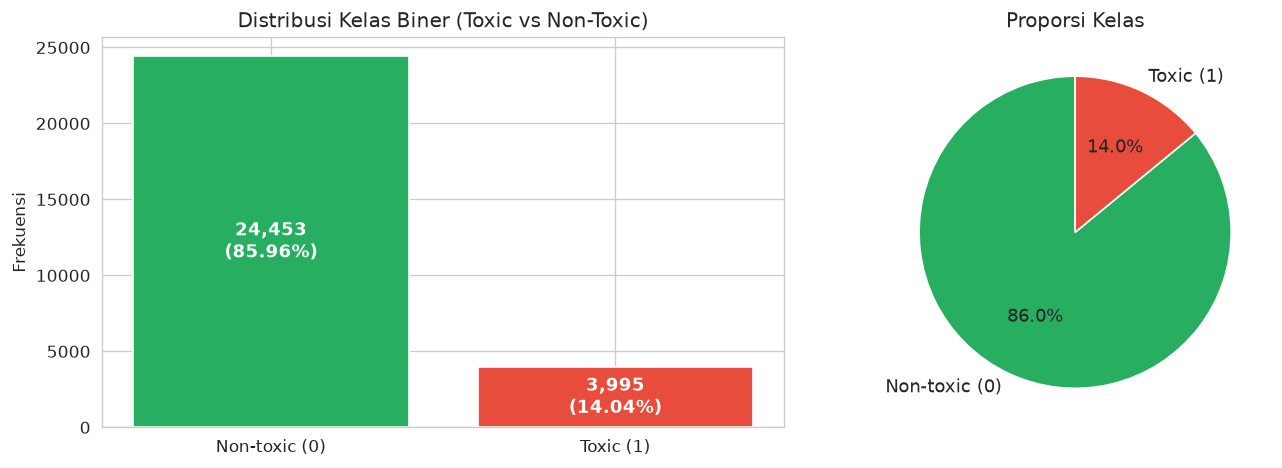

In [10]:
label_counts = df_raw['label'].value_counts()
label_pct = (df_raw['label'].value_counts(normalize=True) * 100).round(2)

dist_df = pd.DataFrame({'Jumlah Sampel': label_counts, 'Persentase (%)': label_pct})
dist_df.index = ['Non-toxic (0)', 'Toxic (1)']
print(dist_df)
print(f"\nRasio Ketidakseimbangan : 1 : {label_counts[0] / label_counts[1]:.1f} (Toxic : Non-toxic)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
ax1 = axes[0]
bars = ax1.bar(dist_df.index, dist_df['Jumlah Sampel'], color=['#27AE60', '#E74C3C'])
for bar, pct in zip(bars, dist_df['Persentase (%)']):
    ax1.annotate(f'{int(bar.get_height()):,}\n({pct}%)',
                 (bar.get_x() + bar.get_width()/2., bar.get_height()/2),
                 ha='center', va='center', color='white', fontweight='bold', fontsize=11)
ax1.set_title('Distribusi Kelas Biner (Toxic vs Non-Toxic)')
ax1.set_ylabel('Frekuensi')

# Pie chart
ax2 = axes[1]
ax2.pie(dist_df['Jumlah Sampel'], labels=dist_df.index, autopct='%1.1f%%',
        colors=['#27AE60', '#E74C3C'], startangle=90, textprops={'fontsize': 11})
ax2.set_title('Proporsi Kelas')

plt.tight_layout()
plt.show()

### 4.3 Distribusi Sub-Kategori Ujaran Kebencian

                 Sub-Kategori  Total Kasus  Persentase (%)
                      insults         1947            6.84
              identity_attack         1756            6.17
threat_incitement_to_violence          786            2.76
          profanity_obscenity          669            2.35
            sexually_explicit          122            0.43


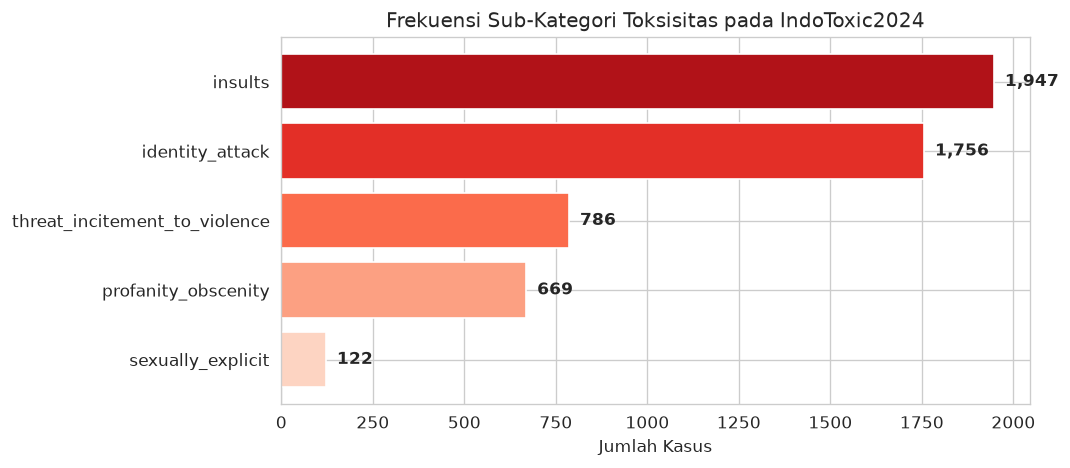

In [11]:
sub_sums = {s: df_raw[f'sub_{s}'].sum() for s in subcategories}
sub_df = pd.DataFrame(list(sub_sums.items()), columns=['Sub-Kategori', 'Total Kasus'])
sub_df['Persentase (%)'] = (sub_df['Total Kasus'] / len(df_raw) * 100).round(2)
sub_df = sub_df.sort_values('Total Kasus', ascending=False).reset_index(drop=True)
print(sub_df.to_string(index=False))

plt.figure(figsize=(9, 4))
bars = plt.barh(sub_df['Sub-Kategori'], sub_df['Total Kasus'], color=sns.color_palette('Reds_r', len(sub_df)))
for bar, val in zip(bars, sub_df['Total Kasus']):
    plt.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontweight='bold')
plt.title('Frekuensi Sub-Kategori Toksisitas pada IndoToxic2024')
plt.xlabel('Jumlah Kasus')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
## 5. Analisis Karakteristik Teks
### 5.1 Statistik Deskriptif Panjang Teks

In [12]:
print("=== Statistik Jumlah Kata per Dokumen ===")
percentiles = [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
print(df_raw['word_count'].describe(percentiles=percentiles).to_string())

print(f"\n=== Statistik Jumlah Karakter per Dokumen ===")
print(df_raw['char_count'].describe(percentiles=percentiles).to_string())

coverage_128 = (df_raw['word_count'] <= Config.MAX_LEN).mean() * 100
print(f"\nCakupan sekuens dengan MAX_LEN = {Config.MAX_LEN}: {coverage_128:.2f}% dari seluruh dataset")

=== Statistik Jumlah Kata per Dokumen ===
count    28448.00000
mean        43.89704
std         71.04390
min          0.00000
25%         12.00000
50%         22.00000
75%         39.00000
90%        107.00000
95%        171.65000
99%        369.06000
max        880.00000

=== Statistik Jumlah Karakter per Dokumen ===
count    28448.000000
mean       309.963231
std        518.918210
min          0.000000
25%         75.000000
50%        145.000000
75%        267.000000
90%        788.000000
95%       1275.000000
99%       2716.180000
max       4998.000000

Cakupan sekuens dengan MAX_LEN = 128: 91.99% dari seluruh dataset


### 5.2 Visualisasi Distribusi Panjang Teks

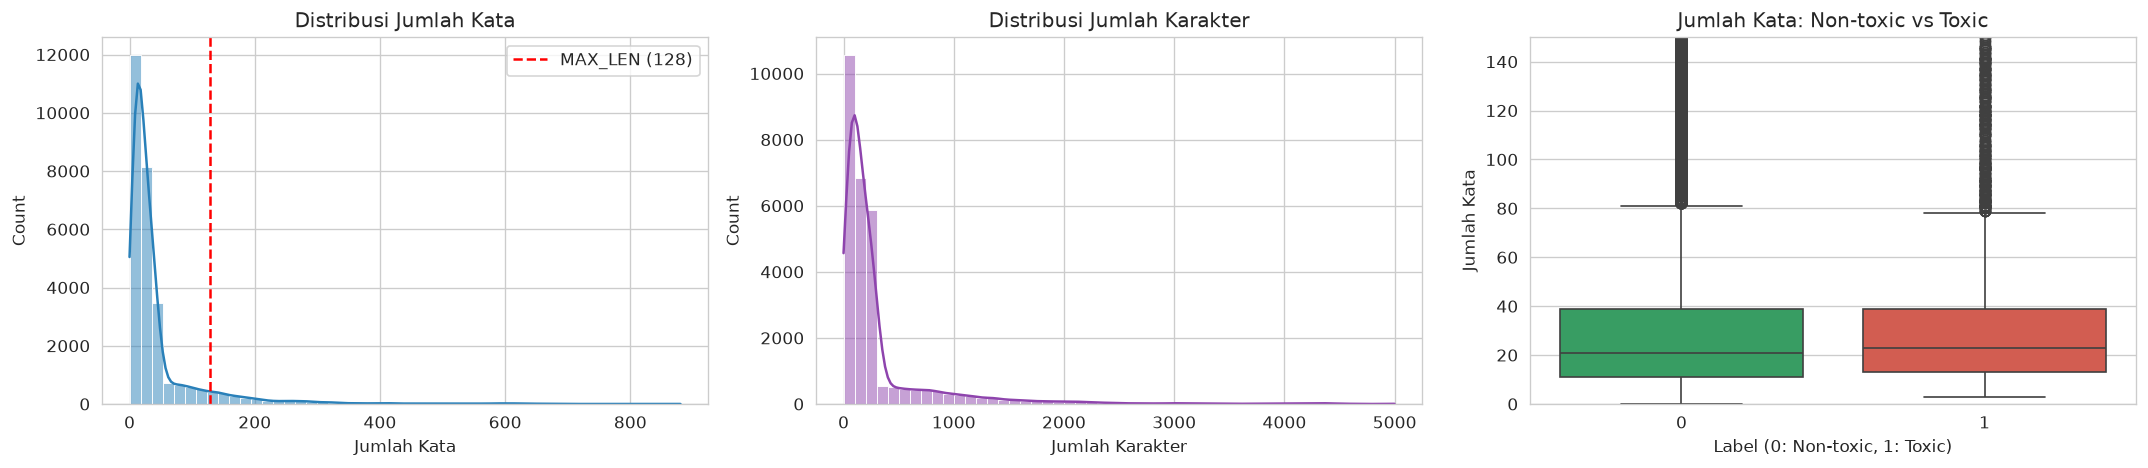

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Histogram jumlah kata
sns.histplot(df_raw['word_count'], bins=50, kde=True, ax=axes[0], color='#2980B9')
axes[0].axvline(Config.MAX_LEN, color='red', linestyle='--', label=f'MAX_LEN ({Config.MAX_LEN})')
axes[0].set_title('Distribusi Jumlah Kata')
axes[0].set_xlabel('Jumlah Kata')
axes[0].legend()

# Histogram jumlah karakter
sns.histplot(df_raw['char_count'], bins=50, kde=True, ax=axes[1], color='#8E44AD')
axes[1].set_title('Distribusi Jumlah Karakter')
axes[1].set_xlabel('Jumlah Karakter')

# Boxplot jumlah kata: Toxic vs Non-toxic
sns.boxplot(data=df_raw, x='label', y='word_count', ax=axes[2], hue='label', palette=['#27AE60', '#E74C3C'], legend=False)
axes[2].set_title('Jumlah Kata: Non-toxic vs Toxic')
axes[2].set_xlabel('Label (0: Non-toxic, 1: Toxic)')
axes[2].set_ylabel('Jumlah Kata')
axes[2].set_ylim(0, 150)

plt.tight_layout()
plt.show()

### 5.3 Rata-rata Panjang Teks per Label

In [14]:
avg_by_label = df_raw.groupby('label')[['word_count', 'char_count']].mean().round(2)
avg_by_label.index = ['Non-toxic (0)', 'Toxic (1)']
avg_by_label.columns = ['Rata-rata Jumlah Kata', 'Rata-rata Jumlah Karakter']
print(avg_by_label)

               Rata-rata Jumlah Kata  Rata-rata Jumlah Karakter
Non-toxic (0)                  45.11                     319.66
Toxic (1)                      36.47                     250.63


---
## 6. Pembersihan Awal Teks & Analisis Kata Dominan
### 6.1 Fungsi Pembersihan Teks Sederhana

In [15]:
# Stopwords bahasa Indonesia sederhana
STOPWORDS_ID = set([
    'yang', 'dan', 'di', 'ini', 'itu', 'dengan', 'untuk', 'pada', 'adalah', 'dari',
    'dalam', 'tidak', 'akan', 'juga', 'sudah', 'saya', 'ke', 'karena', 'ada', 'bisa',
    'kita', 'mereka', 'kami', 'anda', 'dia', 'nya', 'atau', 'tapi', 'jadi', 'kalau',
    'ya', 'apa', 'lagi', 'aja', 'gak', 'ga', 'si', 'kan', 'yg', 'udah', 'mau',
    'kalo', 'nih', 'dong', 'sih', 'deh', 'loh', 'kok', 'kan', 'mah', 'banget',
    'se', 'org', 'dr', 'tp', 'utk', 'dgn', 'blm', 'sdh', 'krn', 'dll', 'dst',
    'the', 'of', 'and', 'to', 'a', 'in', 'is', 'it', 'that', 'this',
    'rt', 'amp', 'https', 'http', 'co', 'com'
])

def clean_text_for_eda(text: str) -> str:
    """Pembersihan teks sederhana untuk keperluan EDA (bukan preprocessing model)."""
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+|t\.co/\S+', '', text)  # Hapus URL
    text = re.sub(r'@\w+', '', text)                              # Hapus mention
    text = re.sub(r'#(\w+)', r'\1', text)                         # Hapus simbol # (pertahankan kata)
    text = re.sub(r'[^\w\s]', '', text)                           # Hapus tanda baca & simbol
    text = re.sub(r'\d+', '', text)                               # Hapus angka
    text = re.sub(r'\s+', ' ', text).strip()                      # Normalkan spasi
    return text

df_raw['text_clean'] = df_raw['text'].apply(clean_text_for_eda)

print("Contoh hasil pembersihan teks:")
for i in range(5):
    print(f"  [RAW]   : {df_raw['text'].iloc[i][:100]}...")
    print(f"  [CLEAN] : {df_raw['text_clean'].iloc[i][:100]}...")
    print()

Contoh hasil pembersihan teks:
  [RAW]   : Wajah Jurnalis Dibalut Perban Saat Melaporkan Kondisi di Gaza 2023...
  [CLEAN] : wajah jurnalis dibalut perban saat melaporkan kondisi di gaza...

  [RAW]   : Elektabilitas Paslon 02 sebentar lagi terjun bebas gara2 Gemoy, joget, susu gratis, makan gratis, po...
  [CLEAN] : elektabilitas paslon sebentar lagi terjun bebas gara gemoy joget susu gratis makan gratis politik di...

  [RAW]   : Gini aja deh @KPU_ID usul aja nih. Gimana kalo misalnya gak usah ada debat aja kalo ga boleh dikriti...
  [CLEAN] : gini aja deh usul aja nih gimana kalo misalnya gak usah ada debat aja kalo ga boleh dikritik diubah ...

  [RAW]   : Relawan Tionghoa Kalbar yg di Jakarta mendeklarasikan dukungan kepada Ganjar Pranowo. Mario Dandy Bu...
  [CLEAN] : relawan tionghoa kalbar yg di jakarta mendeklarasikan dukungan kepada ganjar pranowo mario dandy bu ...

  [RAW]   : Kristen, Hindu, Islam dapat perlakuan istimewa dari pak Anies Ncep ketar-ketir...
  [CLEAN] : kris

### 6.2 Ekstraksi 20 Kata Paling Dominan per Label

In [16]:
def get_top_words(series: pd.Series, n: int = 20) -> pd.DataFrame:
    """Ekstrak N kata paling sering muncul (setelah filter stopwords)."""
    all_words = ' '.join(series).split()
    filtered = [w for w in all_words if w not in STOPWORDS_ID and len(w) > 2]
    counter = Counter(filtered)
    top = counter.most_common(n)
    return pd.DataFrame(top, columns=['Kata', 'Frekuensi'])

top_toxic = get_top_words(df_raw[df_raw['label'] == 1]['text_clean'], 20)
top_nontoxic = get_top_words(df_raw[df_raw['label'] == 0]['text_clean'], 20)

print("=== 20 Kata Dominan pada Kelas TOXIC ===")
print(top_toxic.to_string(index=False))
print(f"\n=== 20 Kata Dominan pada Kelas NON-TOXIC ===")
print(top_nontoxic.to_string(index=False))

=== 20 Kata Dominan pada Kelas TOXIC ===
     Kata  Frekuensi
   israel       2060
palestina        851
    orang        822
     gaza        605
indonesia        584
   zionis        552
    syiah        497
   yahudi        441
    islam        435
     gila        431
     oleh        401
    bukan        350
     sama        324
   negara        320
    hamas        318
    allah        316
    china        306
     para        302
   banyak        284
    semua        273

=== 20 Kata Dominan pada Kelas NON-TOXIC ===
     Kata  Frekuensi
   israel      11178
indonesia       5570
    china       5410
palestina       4759
     gila       4402
     gaza       4297
 rohingya       3672
    orang       3588
     aceh       3348
pengungsi       3115
     oleh       2617
    warga       2572
 tersebut       2529
     hari       2508
    hamas       2351
     para       2198
    telah       1941
     saat       1939
    tahun       1921
   negara       1903


### 6.3 Visualisasi Perbandingan Kata Dominan (Toxic vs Non-Toxic)

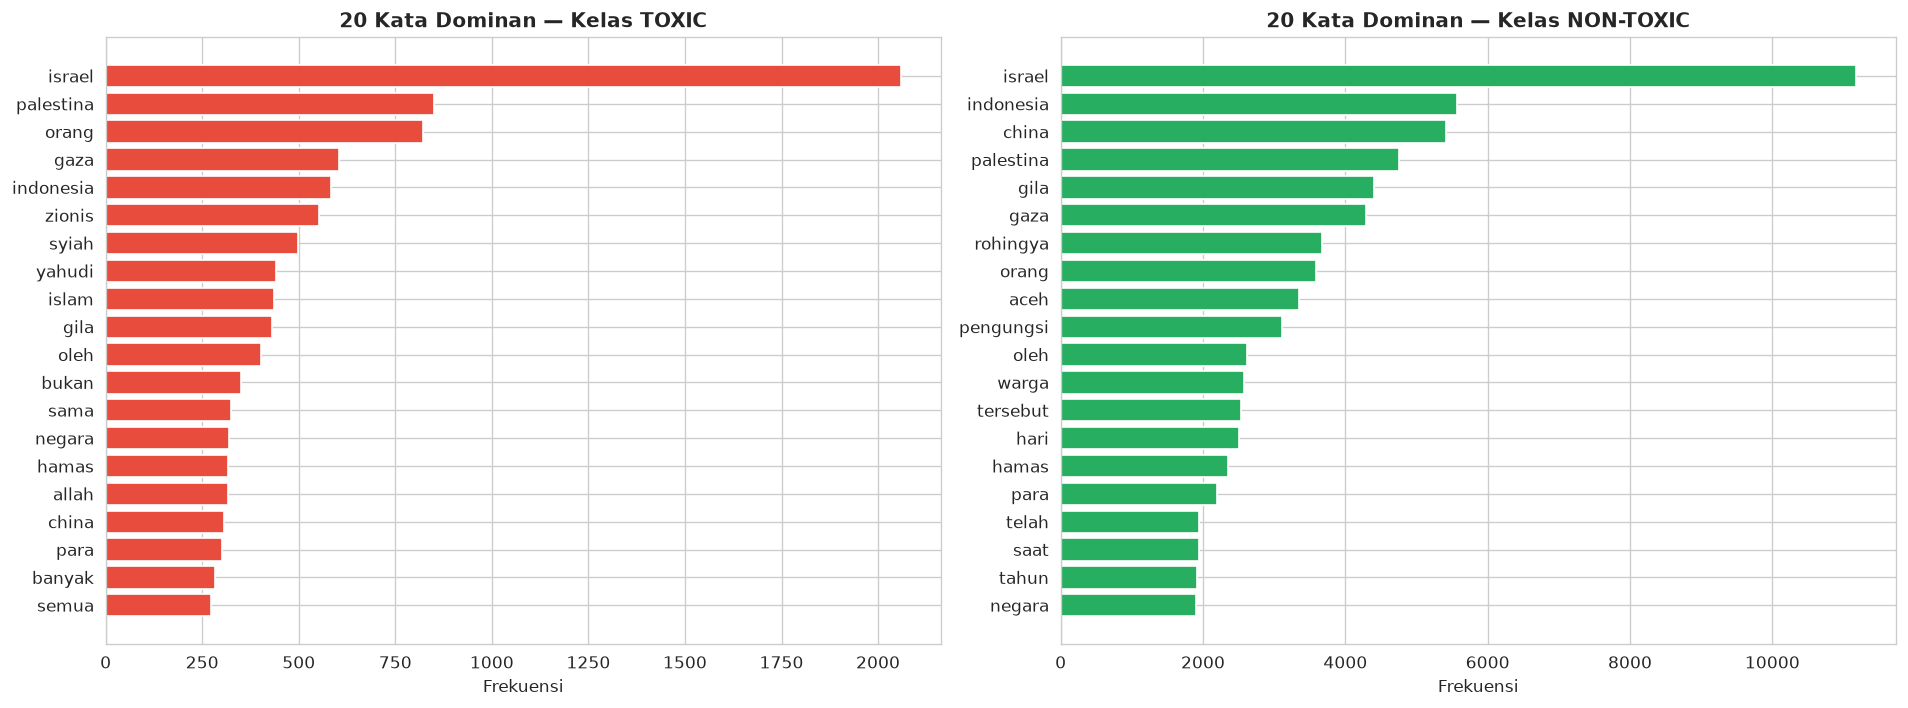

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top words Toxic
ax1 = axes[0]
ax1.barh(top_toxic['Kata'][::-1], top_toxic['Frekuensi'][::-1], color='#E74C3C')
ax1.set_title('20 Kata Dominan — Kelas TOXIC', fontweight='bold')
ax1.set_xlabel('Frekuensi')

# Top words Non-toxic
ax2 = axes[1]
ax2.barh(top_nontoxic['Kata'][::-1], top_nontoxic['Frekuensi'][::-1], color='#27AE60')
ax2.set_title('20 Kata Dominan — Kelas NON-TOXIC', fontweight='bold')
ax2.set_xlabel('Frekuensi')

plt.tight_layout()
plt.show()

### 6.4 Word Cloud (Opsional)

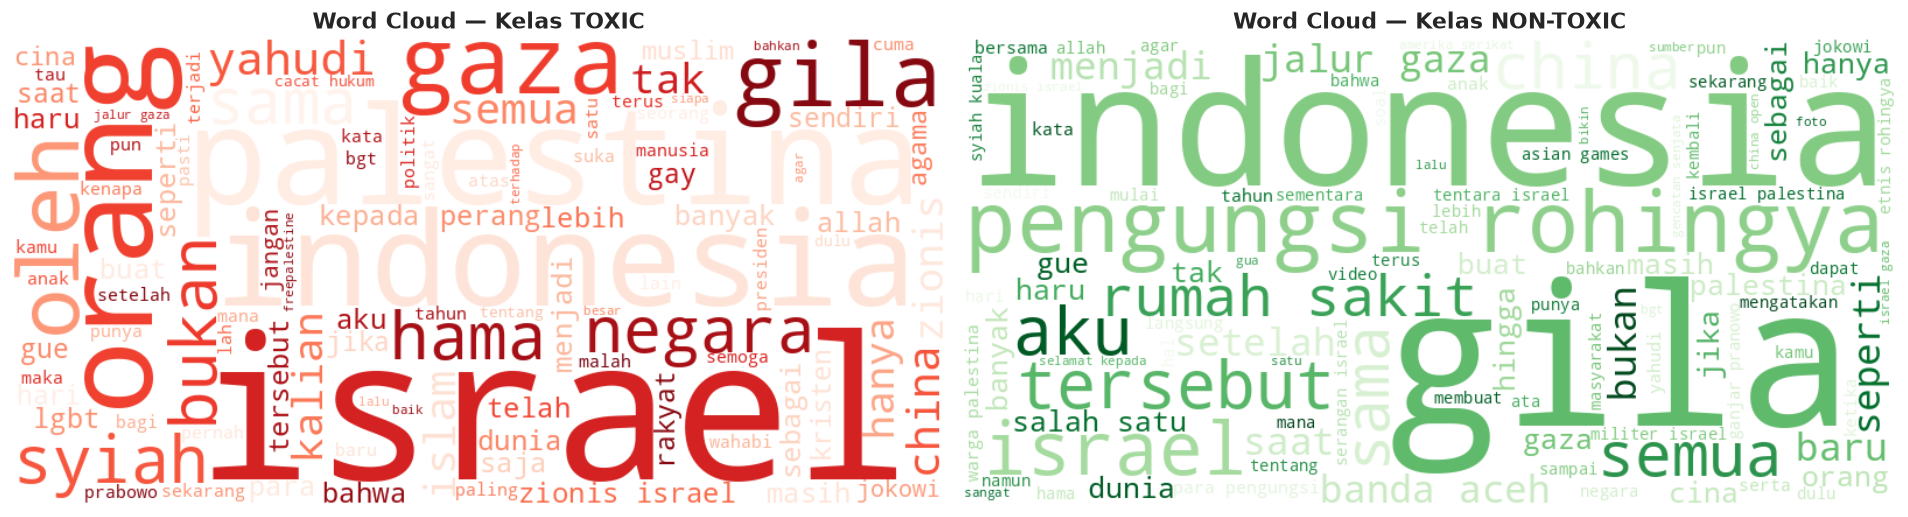

In [18]:
try:
    from wordcloud import WordCloud

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Word Cloud Toxic
    toxic_text = ' '.join(df_raw[df_raw['label'] == 1]['text_clean'])
    toxic_words = ' '.join([w for w in toxic_text.split() if w not in STOPWORDS_ID and len(w) > 2])
    wc_toxic = WordCloud(width=800, height=400, background_color='white',
                         colormap='Reds', max_words=100).generate(toxic_words)
    axes[0].imshow(wc_toxic, interpolation='bilinear')
    axes[0].set_title('Word Cloud — Kelas TOXIC', fontweight='bold', fontsize=13)
    axes[0].axis('off')

    # Word Cloud Non-Toxic
    nontoxic_text = ' '.join(df_raw[df_raw['label'] == 0]['text_clean'])
    nontoxic_words = ' '.join([w for w in nontoxic_text.split() if w not in STOPWORDS_ID and len(w) > 2])
    wc_nontoxic = WordCloud(width=800, height=400, background_color='white',
                            colormap='Greens', max_words=100).generate(nontoxic_words)
    axes[1].imshow(wc_nontoxic, interpolation='bilinear')
    axes[1].set_title('Word Cloud — Kelas NON-TOXIC', fontweight='bold', fontsize=13)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

except ImportError:
    print("Library 'wordcloud' belum terinstal. Jalankan: pip install wordcloud")
    print("Word cloud dilewati. Analisis kata dominan sudah tercakup pada bar chart di atas.")

---
## 7. Analisis Distribusi Topik

                                   Jumlah  Persentase (%)
topic                                                    
Jewish                               8607           30.26
Disabilitas                          6922           24.33
Tionghoa                             5415           19.03
UNKNOWN                              2263            7.95
Rohingya                             1488            5.23
Kristen                              1381            4.85
LGBTQ+                                878            3.09
Syiah                                 532            1.87
Jewish, Rohingya                      187            0.66
Kristen, Jewish                       162            0.57
Ahmadiyah                             126            0.44
Syiah, Jewish                         107            0.38
Jewish, Disabilitas                    93            0.33
Tionghoa, Jewish                       90            0.32
Tionghoa, Disabilitas                  38            0.13
Syiah, Rohingy

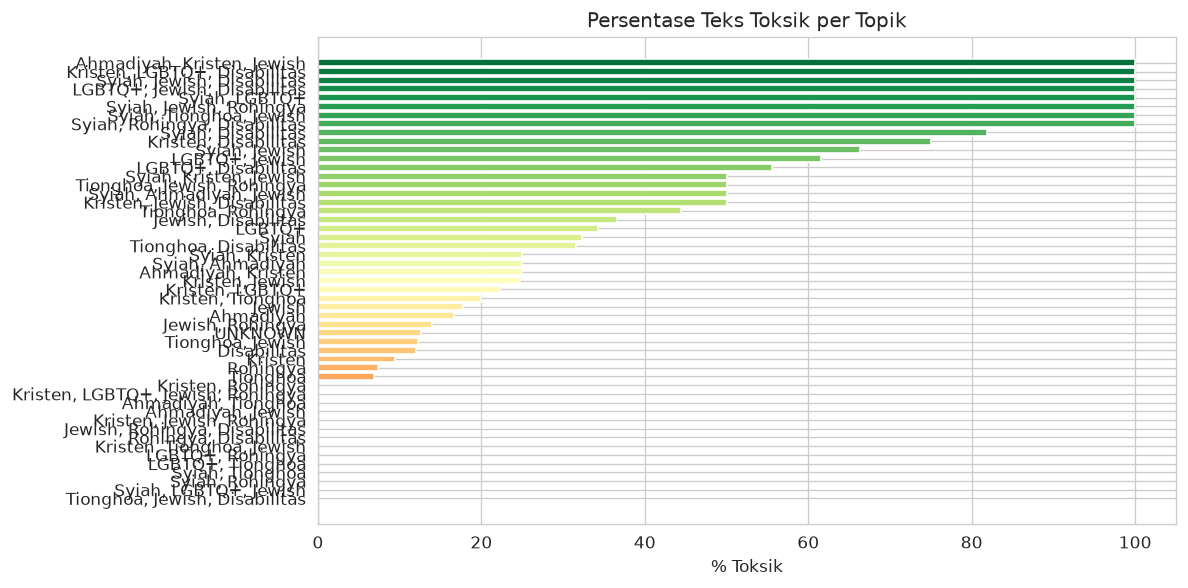

In [19]:
topic_counts = df_raw['topic'].value_counts()
topic_pct = (df_raw['topic'].value_counts(normalize=True) * 100).round(2)
topic_df = pd.DataFrame({'Jumlah': topic_counts, 'Persentase (%)': topic_pct})
print(topic_df)

# Crosstab topik vs label
topic_label = pd.crosstab(df_raw['topic'], df_raw['label'], margins=True)
topic_label.columns = ['Non-toxic', 'Toxic', 'Total']
topic_label['% Toxic'] = (topic_label['Toxic'] / topic_label['Total'] * 100).round(2)
topic_label = topic_label.sort_values('% Toxic', ascending=False)
print(f"\n=== Rasio Toksisitas per Topik ===")
print(topic_label)

plt.figure(figsize=(10, 5))
topic_label_plot = topic_label.drop('All')
plt.barh(topic_label_plot.index, topic_label_plot['% Toxic'], color=sns.color_palette('RdYlGn_r', len(topic_label_plot)))
plt.title('Persentase Teks Toksik per Topik')
plt.xlabel('% Toksik')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
## 8. Analisis Demografi Anotator

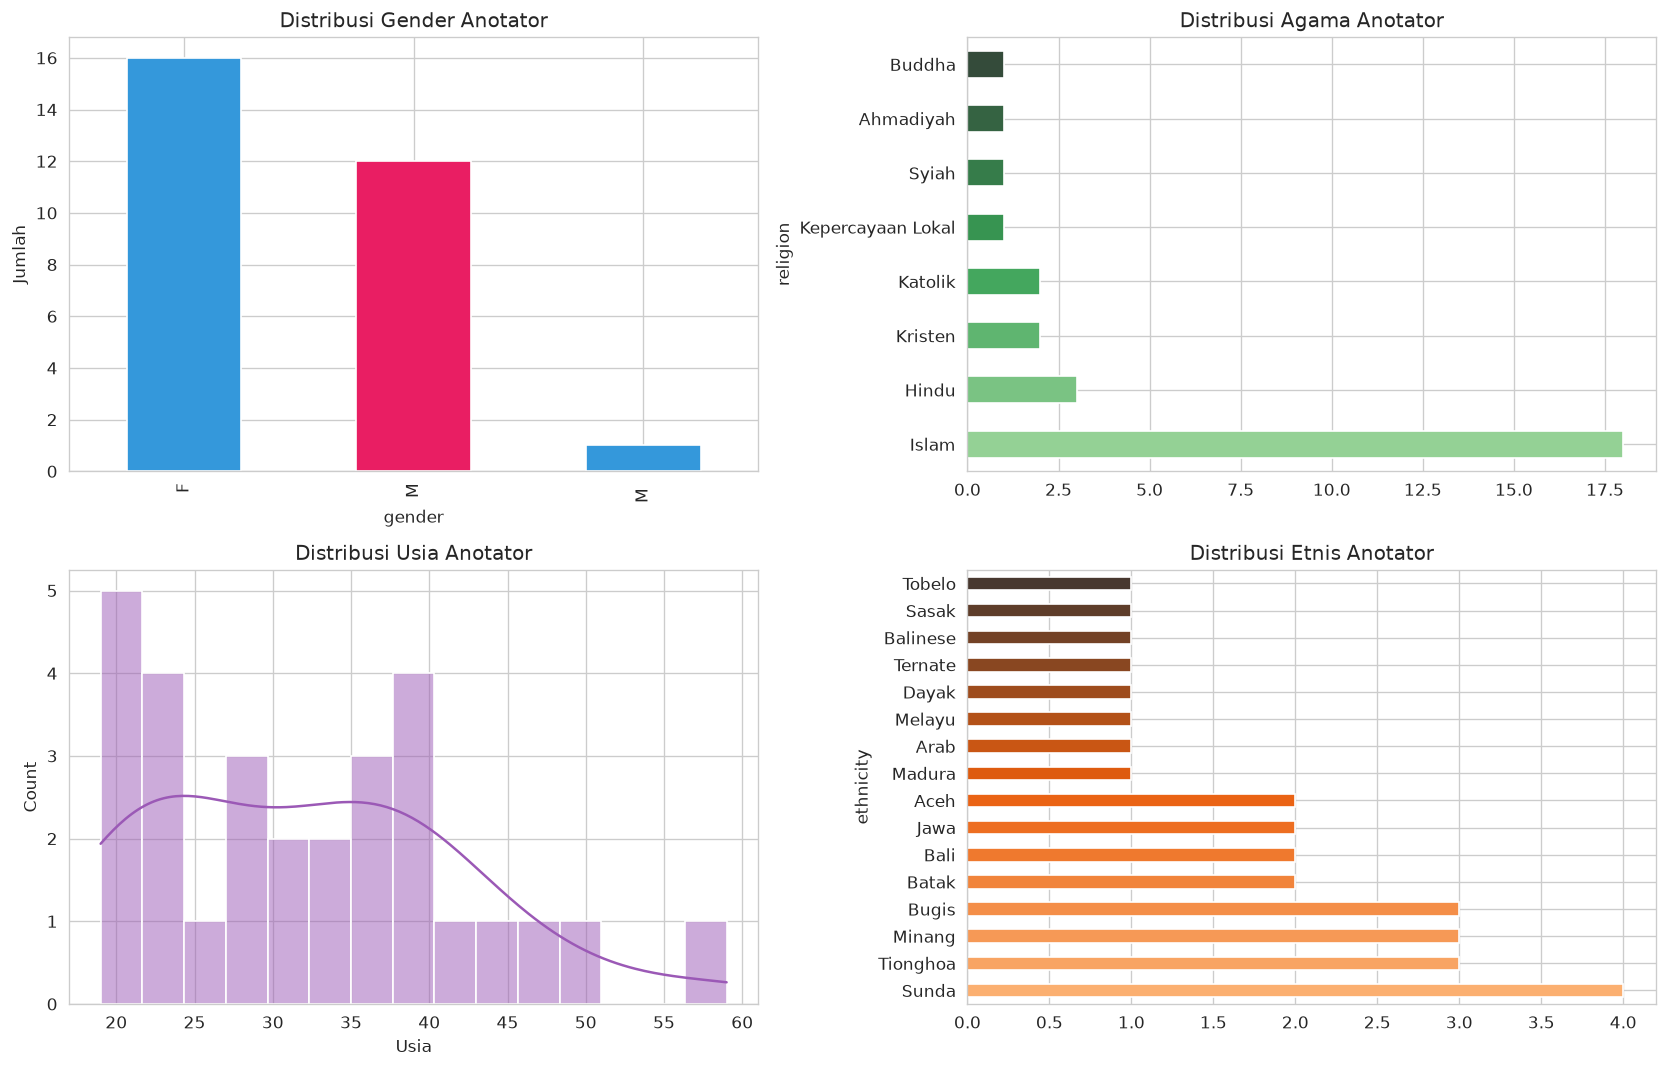

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Gender
df_demo['gender'].value_counts().plot.bar(ax=axes[0,0], color=['#3498DB', '#E91E63'])
axes[0,0].set_title('Distribusi Gender Anotator')
axes[0,0].set_ylabel('Jumlah')

# Agama
df_demo['religion'].value_counts().plot.barh(ax=axes[0,1], color=sns.color_palette('Greens_d', df_demo['religion'].nunique()))
axes[0,1].set_title('Distribusi Agama Anotator')

# Usia
sns.histplot(df_demo['age'], bins=15, kde=True, ax=axes[1,0], color='#9B59B6')
axes[1,0].set_title('Distribusi Usia Anotator')
axes[1,0].set_xlabel('Usia')

# Etnis
df_demo['ethnicity'].value_counts().plot.barh(ax=axes[1,1], color=sns.color_palette('Oranges_d', df_demo['ethnicity'].nunique()))
axes[1,1].set_title('Distribusi Etnis Anotator')

plt.tight_layout()
plt.show()

---
## 9. Kesimpulan & Rekomendasi Persiapan Data

### 9.1 Temuan Kunci EDA

| No | Temuan | Detail |
|---|---|---|
| 1 | **Ukuran Dataset** | 28.448 baris teks media sosial Indonesia dari platform X (Twitter), Instagram, Facebook, dan portal berita. |
| 2 | **Jumlah Kolom** | 14 kolom (1 kolom teks, 1 kolom topik, 7 kolom vote multi-annotator, 5 sub-label toksisitas). |
| 3 | **Multi-Annotator** | 29 anotator dengan latar demografi beragam (suku, agama, gender, usia, kota). |
| 4 | **Severe Class Imbalance** | Non-toxic (~86%) vs Toxic (~14%). Rasio ketidakseimbangan ≈ 1:6. |
| 5 | **Sub-Kategori Dominan** | Insults (6.84%) dan Identity Attack (6.17%) paling mendominasi; Sexually Explicit paling langka (0.43%). |
| 6 | **Panjang Teks** | Median ~20-30 kata. MAX_LEN = 128 mencakup >98% dokumen tanpa pemotongan informasi signifikan. |
| 7 | **Topik Kontekstual** | Rasio toksisitas bervariasi antar-topik — teks bertopik politik/SARA lebih banyak mengandung toksisitas. |

### 9.2 Rekomendasi Preprocessing untuk Pelatihan Model

1. **Normalisasi Leet-Speak & Slang**: Kata makian terselubung (`4nj1ng`, `b4j1ng4n`) harus didekode sebelum tokenisasi agar tidak hilang menjadi token `<OOV>`.
2. **Pembersihan Noise**: Hapus URL, mention (`@user`), hashtag symbols, HTML tags, dan karakter non-ASCII.
3. **Penanganan Imbalance Wajib**: Gunakan **Focal Loss** (`gamma=2.0`, `alpha=0.25`) atau **Balanced Class Weighting** untuk mencegah model bias ke kelas mayoritas Non-toxic.
4. **Encoding Metadata Topik**: Fitur `topic` perlu diencode secara kategorikal (integer ID atau embedding) sebagai input tambahan untuk arsitektur Context-Aware CNN.
5. **Tokenisasi & Padding**: Batasi vocabulary ke 20.000 kata teratas, gunakan post-padding ke MAX_LEN = 128.
6. **Stratified Splitting**: Bagi data dengan proporsi 70/15/15 (Train/Val/Test) secara berstrata berdasarkan label biner untuk menjaga distribusi kelas di setiap partisi.